# Credit Risk Analysis — Phase 3: Model Building
**Goal:** Build Logistic Regression and XGBoost models with SMOTE

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, classification_report, confusion_matrix, roc_curve
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

plt.style.use('seaborn-v0_8')
%matplotlib inline

df = pd.read_csv('data_features.csv')
print('Data loaded:', df.shape)

target_col = 'SeriousDlqin2yrs'
feature_cols = [c for c in df.columns if c != target_col]

X = df[feature_cols]
y = df[target_col]
print(f'Features: {len(feature_cols)}, Samples: {len(X):,}')

Data loaded: (149377, 17)
Features: 16, Samples: 149,377


## Train-Test Split

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f'Train size: {len(X_train):,}')
print(f'Test size:  {len(X_test):,}')
print(f'Train default rate: {y_train.mean()*100:.1f}%')
print(f'Test default rate:  {y_test.mean()*100:.1f}%')

Train size: 119,501
Test size:  29,876
Train default rate: 6.7%
Test default rate:  6.7%


## Handle Class Imbalance with SMOTE

In [3]:
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print('Before SMOTE:')
print(f'  No Default: {(y_train==0).sum():,}')
print(f'  Defaulted:  {(y_train==1).sum():,}')
print(f'\nAfter SMOTE:')
print(f'  No Default: {(y_train_bal==0).sum():,}')
print(f'  Defaulted:  {(y_train_bal==1).sum():,}')

Before SMOTE:
  No Default: 111,495
  Defaulted:  8,006

After SMOTE:
  No Default: 111,495
  Defaulted:  111,495


## Scale Features for Logistic Regression

In [4]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)
print('Features scaled successfully')

Features scaled successfully


## Model 1 — Logistic Regression

In [5]:
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train_bal)

lr_probs = lr.predict_proba(X_test_scaled)[:, 1]
lr_preds = lr.predict(X_test_scaled)
lr_auc = roc_auc_score(y_test, lr_probs)

print('LOGISTIC REGRESSION RESULTS')
print('=' * 45)
print(f'AUC-ROC Score: {lr_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, lr_preds, target_names=['No Default', 'Defaulted']))

LOGISTIC REGRESSION RESULTS
AUC-ROC Score: 0.8228

Classification Report:
              precision    recall  f1-score   support

  No Default       0.97      0.82      0.89     27874
   Defaulted       0.21      0.67      0.32      2002

    accuracy                           0.81     29876
   macro avg       0.59      0.74      0.60     29876
weighted avg       0.92      0.81      0.85     29876



## Model 2 — XGBoost

In [6]:
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)

xgb.fit(X_train_bal, y_train_bal)

xgb_probs = xgb.predict_proba(X_test)[:, 1]
xgb_preds = xgb.predict(X_test)
xgb_auc = roc_auc_score(y_test, xgb_probs)

print('XGBOOST RESULTS')
print('=' * 45)
print(f'AUC-ROC Score: {xgb_auc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, xgb_preds, target_names=['No Default', 'Defaulted']))

XGBOOST RESULTS
AUC-ROC Score: 0.8587

Classification Report:
              precision    recall  f1-score   support

  No Default       0.96      0.93      0.95     27874
   Defaulted       0.36      0.51      0.42      2002

    accuracy                           0.91     29876
   macro avg       0.66      0.72      0.69     29876
weighted avg       0.92      0.91      0.91     29876



## Model Comparison — ROC Curves

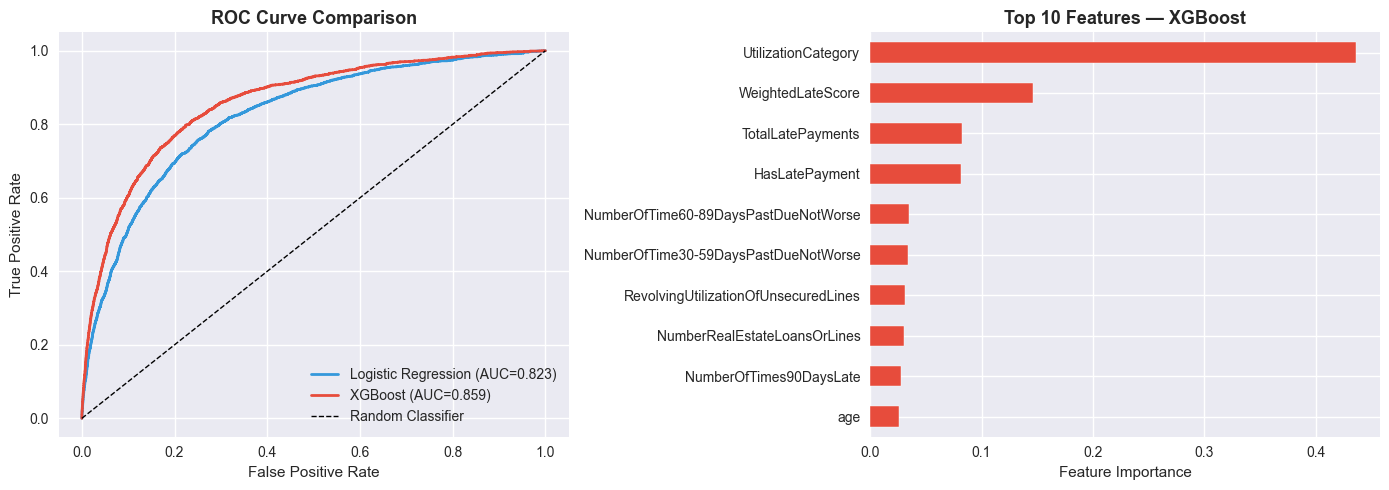

Logistic Regression AUC: 0.8228
XGBoost AUC:             0.8587
Winner: XGBoost


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for probs, label, color in [
    (lr_probs, f'Logistic Regression (AUC={lr_auc:.3f})', '#3498db'),
    (xgb_probs, f'XGBoost (AUC={xgb_auc:.3f})', '#e74c3c')
]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    axes[0].plot(fpr, tpr, label=label, color=color, linewidth=2)

axes[0].plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison', fontsize=13, fontweight='bold')
axes[0].legend()

feat_imp = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=True).tail(10)
feat_imp.plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Top 10 Features — XGBoost', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Feature Importance')

plt.tight_layout()
plt.savefig('plots/07_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Logistic Regression AUC: {lr_auc:.4f}')
print(f'XGBoost AUC:             {xgb_auc:.4f}')
winner = 'XGBoost' if xgb_auc > lr_auc else 'Logistic Regression'
print(f'Winner: {winner}')

## Confusion Matrix

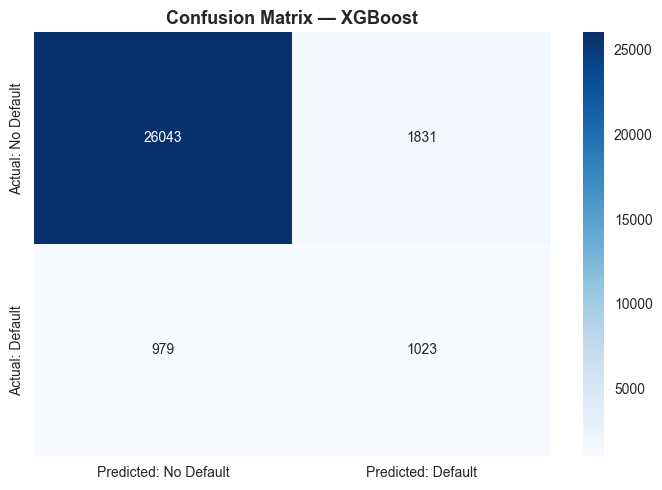

True Positives  (defaulters caught):      1,023
False Negatives (defaulters missed):      979
False Positives (good customers rejected):1,831
True Negatives  (good customers approved):26,043

Recall (defaulters caught): 51.1%


In [8]:
cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Default', 'Predicted: Default'],
            yticklabels=['Actual: No Default', 'Actual: Default'])
plt.title('Confusion Matrix — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/08_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f'True Positives  (defaulters caught):      {tp:,}')
print(f'False Negatives (defaulters missed):      {fn:,}')
print(f'False Positives (good customers rejected):{fp:,}')
print(f'True Negatives  (good customers approved):{tn:,}')
print(f'\nRecall (defaulters caught): {tp/(tp+fn)*100:.1f}%')

## Save Models

In [9]:
import pickle

with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)
with open('lr_model.pkl', 'wb') as f:
    pickle.dump(lr, f)
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

results_df = X_test.copy()
results_df['actual'] = y_test.values
results_df['xgb_prob'] = xgb_probs
results_df['lr_prob'] = lr_probs
results_df.to_csv('model_predictions.csv', index=False)

print('All models and predictions saved!')
print(f'Final XGBoost AUC: {xgb_auc:.4f}')

All models and predictions saved!
Final XGBoost AUC: 0.8587
